In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [2]:
# combine piControl 1 year runs (50 files) into a single 500 year file
# do for various monthly ocean and atmosphere variables
ds_temp_ocn = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_activeTracers_temperature.*.nc'
)

In [3]:
ds_temp_ocn = ds_temp_ocn.assign_coords(time=ds_temp_ocn['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))

In [4]:
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
  * time                                       (time) object 48kB 0001-01-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [5]:
#ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'][0,0].plot.pcolormesh()

In [6]:
# check shapes of files
# make sure ocean lat/lon is consistent 
# different grids between atmosphere and ocean will make the have different shapes 

print(ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'].shape)

(6000, 60, 180, 360)


In [7]:
# slice datasets to tropical pacific region 
# slice each variable and output new file name 

ds_temp_ocn_tp = ds_temp_ocn.sel(lat=slice(-5,5), lon=slice(190,240))

In [8]:
ds_temp_ocn_tp

<xarray.Dataset> Size: 750MB
Dimensions:                                    (time: 6000, lat: 10, nbnd: 2,
                                                lon: 50, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 80B -4.5 ... 4.5
  * lon                                        (lon) float64 400B 190.5 ... 2...
  * time                                       (time) object 48kB 0001-01-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 960kB dask.array<chunksize=(120, 10, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 5MB dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 480kB dask.array<chunksize=(120, 10), meta=np.ndarray>
    area                                       (time, lat, lon) float64 24MB dask.array<chunksize=(120, 10, 50), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 720MB dask.array<chunksize=(120, 60, 10, 50), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [9]:
# plot using .pcolormesh() to for sanity check that slice was to tropical pacific region
#ds_temp_ocn_tp['timeMonthly_avg_activeTracers_temperature'][0,0].plot.pcolormesh()

In [10]:
# ocean temperature has 60 depth levels, choose sea surface temp for analysis. 
# this will make all of the arrays have the format: time, lat, lon
print(ds_temp_ocn_tp['timeMonthly_avg_activeTracers_temperature'][:,0].shape)

(6000, 10, 50)


In [11]:
# save out new variables with updated shapes (ocean most important here)

sst = ds_temp_ocn_tp['timeMonthly_avg_activeTracers_temperature'][:,0]

In [12]:
sst

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 10, lon: 50)> Size: 12MB
dask.array<getitem, shape=(6000, 10, 50), dtype=float32, chunksize=(120, 10, 50), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon      (lon) float64 400B 190.5 191.5 192.5 193.5 ... 237.5 238.5 239.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [13]:
# create climatology using groupby
# take the mean over time to get a monthly climatology that can be applied 

sst_climatology = sst.groupby('time.month').mean(dim='time',
                                                         keep_attrs=True)

In [14]:
sst_climatology

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (month: 12,
                                                               lat: 10, lon: 50)> Size: 24kB
dask.array<stack, shape=(12, 10, 50), dtype=float32, chunksize=(1, 10, 50), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon      (lon) float64 400B 190.5 191.5 192.5 193.5 ... 237.5 238.5 239.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [15]:
# calculate sst anomalies by taking sst and groupby month, subtract by new climatology
sst_anomalies = sst.groupby('time.month') - sst_climatology

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


In [16]:
sst_anomalies

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 10, lon: 50)> Size: 12MB
dask.array<sub, shape=(6000, 10, 50), dtype=float32, chunksize=(1, 10, 50), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon      (lon) float64 400B 190.5 191.5 192.5 193.5 ... 237.5 238.5 239.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [17]:
# check dimensions 
#sst_anomalies[0].plot.pcolormesh()
#plt.show()
#sst_anomalies[1].plot.pcolormesh()
#plt.show()

## Take Spatial Average of Lat/Lon

In [18]:
nino34_spatial = np.mean(sst_anomalies, axis=(1,2))

In [19]:
nino34_spatial

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 24kB
dask.array<mean_agg-aggregate, shape=(6000,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [20]:
oni = nino34_spatial.rolling(time=3, center=True).mean()

In [21]:
oni

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 24kB
dask.array<truediv, shape=(6000,), dtype=float32, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [22]:
# create dictionary of season labels
# already computed 3 month rolling means (center=True)
# this means jan = DJF, feb = JFM, etc.

month_to_season = {
    1: 'DJF',
    2: 'JFM',
    3: 'FMA',
    4: 'MAM',
    5: 'AMJ',
    6: 'MJJ',
    7: 'JJA',
    8: 'JAS',
    9: 'ASO',
    10: 'SON',
    11: 'OND',
    12: 'NDJ'
}

In [23]:
# Correct version:
season_labels = [month_to_season[m] for m in oni['month'].values]

oni = oni.assign_coords(season=('time', season_labels))

In [24]:
oni

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 24kB
dask.array<truediv, shape=(6000,), dtype=float32, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    season   (time) <U3 72kB 'DJF' 'JFM' 'FMA' 'MAM' ... 'ASO' 'SON' 'OND' 'NDJ'

## assign ENSO phase

In [25]:
enso_phase = np.full(oni.shape, 'Neutral', dtype=object)

In [26]:
enso_phase

array(['Neutral', 'Neutral', 'Neutral', ..., 'Neutral', 'Neutral',
       'Neutral'], dtype=object)

In [27]:
el_nino_mask = oni > 0.5
la_nina_mask = oni < -0.5

In [28]:
el_nino_persistent = el_nino_mask.rolling(time=5, center=False).sum() == 5

In [29]:
el_nino_persistent

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 6kB
dask.array<eq, shape=(6000,), dtype=bool, chunksize=(7,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    season   (time) <U3 72kB 'DJF' 'JFM' 'FMA' 'MAM' ... 'ASO' 'SON' 'OND' 'NDJ'

In [30]:
la_nina_persistent = la_nina_mask.rolling(time=5, center=False).sum() == 5

In [31]:
la_nina_persistent

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 6kB
dask.array<eq, shape=(6000,), dtype=bool, chunksize=(7,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    season   (time) <U3 72kB 'DJF' 'JFM' 'FMA' 'MAM' ... 'ASO' 'SON' 'OND' 'NDJ'

In [32]:
enso_phase[np.where(el_nino_persistent)] = 'El Niño'
enso_phase[np.where(la_nina_persistent)] = 'La Niña'

In [33]:
oni = oni.assign_coords(enso_phase=('time', enso_phase))

In [34]:
oni

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 24kB
dask.array<truediv, shape=(6000,), dtype=float32, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time        (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month       (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
    season      (time) <U3 72kB 'DJF' 'JFM' 'FMA' 'MAM' ... 'SON' 'OND' 'NDJ'
    enso_phase  (time) object 48kB 'Neutral' 'Neutral' ... 'La Niña' 'Neutral'

In [42]:
import pandas as pd

# Convert enso_phase into a pandas Series (if it's not already)
enso_phase_series = pd.Series(enso_phase)

# Count occurrences of each unique value
event_counts = enso_phase_series.value_counts()

print(event_counts)

Neutral    4350
El Niño     831
La Niña     819
Name: count, dtype: int64


In [35]:
# Step 1: Convert phases into a Pandas Series
enso_series = pd.Series(oni['enso_phase'].values, index=oni['time'].values)

# Step 2: Identify when phase changes occur
phase_change = enso_series != enso_series.shift(1)

# Step 3: Label each continuous event with a unique ID
event_id = phase_change.cumsum()

# Step 4: Group by event_id and find the phase and length of each event
event_info = enso_series.groupby(event_id).agg(['first', 'size'])

# Step 5: Filter by phase type and size
# Optionally: Only count events that actually meet 5-month persistence (you already did 5-season persistence before)
el_nino_events = event_info[event_info['first'] == 'El Niño']
la_nina_events = event_info[event_info['first'] == 'La Niña']
neutral_events = event_info[event_info['first'] == 'Neutral']

# Step 6: Print how many full events
print(f"Number of El Niño events: {len(el_nino_events)}")
print(f"Number of La Niña events: {len(la_nina_events)}")
print(f"Number of Neutral periods: {len(neutral_events)}")

Number of El Niño events: 140
Number of La Niña events: 139
Number of Neutral periods: 280


In [38]:
el_nino_events

,first,size
4,El Niño,5
8,El Niño,9
10,El Niño,8
14,El Niño,1
18,El Niño,2
...,...,...
548,El Niño,5
550,El Niño,5
552,El Niño,1
554,El Niño,1


In [39]:
la_nina_events

,first,size
2,La Niña,1
6,La Niña,5
12,La Niña,4
16,La Niña,3
32,La Niña,7
...,...,...
536,La Niña,6
542,La Niña,5
544,La Niña,5
546,La Niña,1


In [36]:
oni = oni.load()

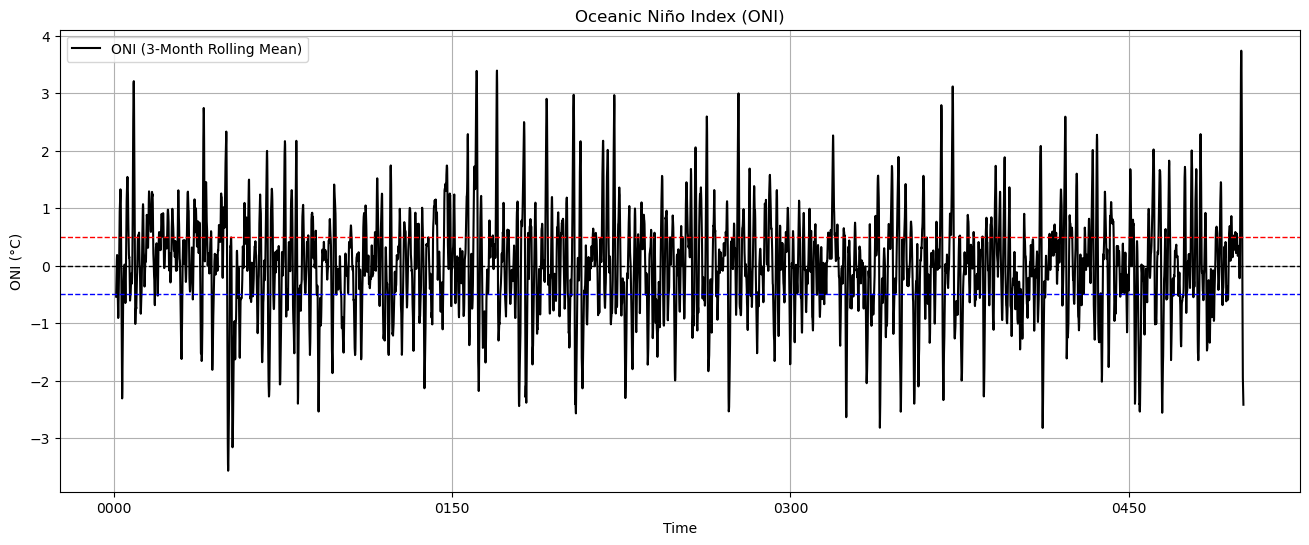

In [37]:
# Plot the ONI timeseries
plt.figure(figsize=(16, 6))

# xarray's plot
oni.plot(label='ONI (3-Month Rolling Mean)', color='black')

# Add zero line
plt.axhline(0, color='black', linewidth=1, linestyle='--')  # Add a zero line for reference
plt.axhline(0.5, color='red', linewidth=1, linestyle='--')  
plt.axhline(-0.5, color='blue', linewidth=1, linestyle='--')  

plt.title('Oceanic Niño Index (ONI)')
plt.xlabel('Time')
plt.ylabel('ONI (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
ds = oni.to_dataset(name='oni')
ds.to_netcdf('oni_e3sm_0502.nc')

In [39]:
ds_test = xr.open_dataset('oni_e3sm_0502.nc')

In [43]:
ds_test.coords

Coordinates:
  * time        (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month       (time) int64 48kB ...
    season      (time) <U3 72kB ...
    enso_phase  (time) <U7 168kB ...

In [41]:
ds_test['oni']

<xarray.DataArray 'oni' (time: 6000)> Size: 24kB
[6000 values with dtype=float32]
Coordinates:
  * time        (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month       (time) int64 48kB ...
    season      (time) <U3 72kB ...
    enso_phase  (time) <U7 168kB ...

In [47]:
print(ds_test['enso_phase'].values[:10])
print(np.unique(ds_test['season'].values))
print(ds_test['month'].values)

['Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Neutral' 'Neutral']
['AMJ' 'ASO' 'DJF' 'FMA' 'JAS' 'JFM' 'JJA' 'MAM' 'MJJ' 'NDJ' 'OND' 'SON']
[ 1  2  3 ... 10 11 12]
